In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from transformers import WhisperForAudioClassification, WhisperProcessor
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report, balanced_accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
import random
from sklearn.model_selection import KFold

/home/fnst/Desktop/shendabadi/whisper_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

## data preprocessing

In [3]:
reset_seed(42)

whisper_tiny_processor = WhisperProcessor.from_pretrained('whisper_small')


emo2num = {
    'H' : 0,
    'N' : 1,
    'S' : 2,
    'A' : 3,
    'W' : 4
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger',
    4 : 'Wonder'
}


audios = []
sample_rates = []
emotions = []
labels = []
file_names = []
file_paths = []
features = []

pattern = r'^...(.)'

for root, folders, files in os.walk('shemo'):
    for filename in files:
        file_path = os.path.join(root, filename)
        audio_data, sr = librosa.load(file_path, sr=16000)
        
        input_features = whisper_tiny_processor(audio_data, sampling_rate=sr, return_tensors="pt").input_features
    

        match = re.search(pattern, filename)
        if match:
            char = match.group(1)
            if char in ['H', 'N', 'S', 'W', 'A']:
                audios.append(audio_data)
                sample_rates.append(sr)
                # emotion = 'H' if char == 'W' else char
                emotion = char
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                features.append(input_features.squeeze(0))
                file_names.append(filename)
                file_paths.append(file_path)

In [4]:
kf = KFold(n_splits=5, random_state=42, shuffle=True)
kf.get_n_splits(features)

5

In [5]:
for i, (train_index, test_index) in enumerate(kf.split(features)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[   0    1    2 ... 2958 2959 2960]
  Test:  index=[   7   12   29   30   32   43   44   45   51   56   63   67   70   73
   80   87   93   96  102  104  108  111  120  124  134  135  139  141
  144  149  152  162  168  170  173  174  175  177  178  183  184  188
  192  194  196  199  203  210  211  212  218  221  226  231  233  239
  246  251  254  256  257  270  272  282  283  289  291  296  298  309
  313  314  318  321  322  324  331  332  351  354  365  366  367  368
  387  393  402  407  408  410  411  414  415  420  422  423  430  432
  433  436  439  443  450  457  460  463  464  471  478  479  485  486
  495  498  506  507  509  511  521  527  528  532  533  535  543  544
  554  555  557  564  565  567  568  572  581  594  598  599  602  605
  610  612  637  642  644  650  651  670  676  677  678  679  685  693
  695  700  705  727  736  741  742  744  746  748  761  764  765  772
  781  783  785  789  807  809  811  817  819  829  838  839  840  842
  8

In [6]:
(train_index1, test_index1), (train_index2, test_index2),(train_index3, test_index3),(train_index4, test_index4),(train_index5, test_index5) = kf.split(features)

In [7]:
################# Train_features
trainF1features = [value for index, value in enumerate(features) if index in train_index1]
trainF2features = [value for index, value in enumerate(features) if index in train_index2]
trainF3features = [value for index, value in enumerate(features) if index in train_index3]
trainF4features = [value for index, value in enumerate(features) if index in train_index4]
trainF5features = [value for index, value in enumerate(features) if index in train_index5]

################# Train_labels
trainF1labels = [value for index, value in enumerate(labels) if index in train_index1]
trainF2labels = [value for index, value in enumerate(labels) if index in train_index2]
trainF3labels = [value for index, value in enumerate(labels) if index in train_index3]
trainF4labels = [value for index, value in enumerate(labels) if index in train_index4]
trainF5labels = [value for index, value in enumerate(labels) if index in train_index5]

################# Test_features
testF1features = [value for index, value in enumerate(features) if index in test_index1]
testF2features = [value for index, value in enumerate(features) if index in test_index2]
testF3features = [value for index, value in enumerate(features) if index in test_index3]
testF4features = [value for index, value in enumerate(features) if index in test_index4]
testF5features = [value for index, value in enumerate(features) if index in test_index5]

################# Test_labels
testF1labels = [value for index, value in enumerate(labels) if index in test_index1]
testF2labels = [value for index, value in enumerate(labels) if index in test_index2]
testF3labels = [value for index, value in enumerate(labels) if index in test_index3]
testF4labels = [value for index, value in enumerate(labels) if index in test_index4]
testF5labels = [value for index, value in enumerate(labels) if index in test_index5]

################## Train_names
trainF1names = [value for index, value in enumerate(file_names) if index in train_index1]
trainF2names = [value for index, value in enumerate(file_names) if index in train_index2]
trainF3names = [value for index, value in enumerate(file_names) if index in train_index3]
trainF4names = [value for index, value in enumerate(file_names) if index in train_index4]
trainF5names = [value for index, value in enumerate(file_names) if index in train_index5]

################# Train_paths
trainF1paths = [value for index, value in enumerate(file_paths) if index in train_index1]
trainF2paths = [value for index, value in enumerate(file_paths) if index in train_index2]
trainF3paths = [value for index, value in enumerate(file_paths) if index in train_index3]
trainF4paths = [value for index, value in enumerate(file_paths) if index in train_index4]
trainF5paths = [value for index, value in enumerate(file_paths) if index in train_index5]

################# Test_names
testF1names = [value for index, value in enumerate(file_names) if index in test_index1]
testF2names = [value for index, value in enumerate(file_names) if index in test_index2]
testF3names = [value for index, value in enumerate(file_names) if index in test_index3]
testF4names = [value for index, value in enumerate(file_names) if index in test_index4]
testF5names = [value for index, value in enumerate(file_names) if index in test_index5]

################# Test_paths
testF1paths = [value for index, value in enumerate(file_paths) if index in test_index1]
testF2paths = [value for index, value in enumerate(file_paths) if index in test_index2]
testF3paths = [value for index, value in enumerate(file_paths) if index in test_index3]
testF4paths = [value for index, value in enumerate(file_paths) if index in test_index4]
testF5paths = [value for index, value in enumerate(file_paths) if index in test_index5]

In [9]:
reset_seed(42)
class AudioDataSet(Dataset):
    def __init__(self, features, labels, file_names=None, file_paths=None):
        self.features = features
        self.labels = labels
        self.index = list(range(len(labels)))
        self.filename = file_names
        self.filepath = file_paths


    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'label': torch.Tensor([self.labels[index]]),  # Convert to PyTorch tensor if not already
            'name' : self.filename[index],
            'path' : self.filepath[index],
            'gender': self.filename[index][0],
            'index': self.index[index]
        }


        return sample


Fold1train = AudioDataSet(trainF1features, trainF1labels, trainF1names, trainF1paths)
Fold1test = AudioDataSet(testF1features, testF1labels, testF1names, testF1paths)

Fold2train = AudioDataSet(trainF2features, trainF2labels, trainF2names, trainF2paths)
Fold2test = AudioDataSet(testF2features, testF2labels, testF2names, testF2paths)

Fold3train = AudioDataSet(trainF3features, trainF3labels, trainF3names, trainF3paths)
Fold3test = AudioDataSet(testF3features, testF3labels, testF3names, testF3paths)

Fold4train = AudioDataSet(trainF4features, trainF4labels, trainF4names, trainF4paths)
Fold4test = AudioDataSet(testF4features, testF4labels, testF4names, testF4paths)

Fold5train = AudioDataSet(trainF5features, trainF5labels, trainF5names, trainF5paths)
Fold5test = AudioDataSet(testF5features, testF5labels, testF5names, testF5paths)

In [10]:
folds_trains = [Fold1train, Fold2train, Fold3train, Fold4train, Fold5train]
folds_vals = [Fold1test, Fold2test, Fold3test, Fold4test, Fold5test]
folds_indices = [train_index1, train_index2, train_index3, train_index4, train_index5]

## train test and arch

In [10]:
reset_seed(42)
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs =10, patience=4):
  training_losses = []
  valid_losses = []
  durations = []
  best_val_loss = float('inf')
  best_val_accuracy = 0.0
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    valid_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): # Each batch, One Iteration
      optimizer.zero_grad()
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs)
      loss = loss_fn(output, targets)
      loss.backward()
      optimizer.step()
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration

      training_loss.append(loss.data.item())
    training_loss = np.mean(training_loss)
    training_losses.append(training_loss)
    

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs)
      loss = loss_fn(output, targets)
      valid_loss.append(loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(output, dim=1), dim=1), targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration
      
    valid_loss = np.mean(valid_loss)
    valid_losses.append(valid_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)
    valid_accuracy = num_correct / num_examples

    print(f'Epoch: {epoch+1} finished in {duration:.2f} seconds, Training Loss: {training_loss: .2f}, Validation Loss: {valid_loss:.2f}, Validation Accuracy: {valid_accuracy : .2f}')

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        current_patience = 0
    else:
        current_patience += 1

    if valid_accuracy > best_val_accuracy:
      best_val_accuracy = valid_accuracy
      torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses

In [11]:
def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()

    for target in targets:
      labels.append(target.item())
    inputs, targets = inputs.to(device), targets.to(device)
    output = model(inputs)
    for out in output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(output, targets)
    test_loss.append(loss.data.item())
    inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'Wonder'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'Wonder'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss} | U_Accuracy: {u_acc} | W_Accuracy: {w_acc} | Precision: {precision} | Recall: {recall} | f1: {f1}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

In [12]:
reset_seed(42)

class WhisAttSumModel (nn.Module):
  def __init__(self):
    super(WhisAttSumModel, self).__init__()
    self.whisperencoder = WhisperForAudioClassification.from_pretrained('whisper_small').encoder.to(device)
    self.projector = WhisperForAudioClassification.from_pretrained('whisper_small').projector.to(device)
    self.layernorm = nn.LayerNorm(256)
    self.attention_scorer = nn.Linear(in_features=256, out_features=1, bias=True)
    self.classifier = torch.nn.Linear(in_features=256, out_features=5)

  def forward(self, x):
    out = self.whisperencoder(x).last_hidden_state
    out = self.projector(out)
    out = self.layernorm(out)
    attention_scores = self.attention_scorer(out)
    attention_weights = F.softmax(attention_scores, dim=1)
    weighted_output = out*attention_weights
    weighted_mean_pooled_output = weighted_output.sum(dim=1)
    out = self.classifier(weighted_mean_pooled_output)

    return out

## training

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 409.14 seconds, Training Loss:  0.54, Validation Loss: 0.49, Validation Accuracy:  0.83


Epoch: 2 finished in 409.33 seconds, Training Loss:  0.30, Validation Loss: 0.48, Validation Accuracy:  0.82


Epoch: 3 finished in 409.63 seconds, Training Loss:  0.24, Validation Loss: 0.47, Validation Accuracy:  0.83


Epoch: 4 finished in 409.70 seconds, Training Loss:  0.21, Validation Loss: 0.44, Validation Accuracy:  0.86


...

Epoch: 6 finished in 409.77 seconds, Training Loss:  0.17, Validation Loss: 0.49, Validation Accuracy:  0.83


Epoch: 7 finished in 409.89 seconds, Training Loss:  0.15, Validation Loss: 0.51, Validation Accuracy:  0.83


Epoch: 8 finished in 409.99 seconds, Training Loss:  0.14, Validation Loss: 0.51, Validation Accuracy:  0.82


Epoch: 9 finished in 410.01 seconds, Training Loss:  0.13, Validation Loss: 0.51, Validation Accuracy:  0.83


Epoch: 10 finished in 410.06 seconds, Training Loss:  0.12, Validation Loss: 0.53, Validation Accuracy:  0.82
Each epoch took 409.72 seconds in average.


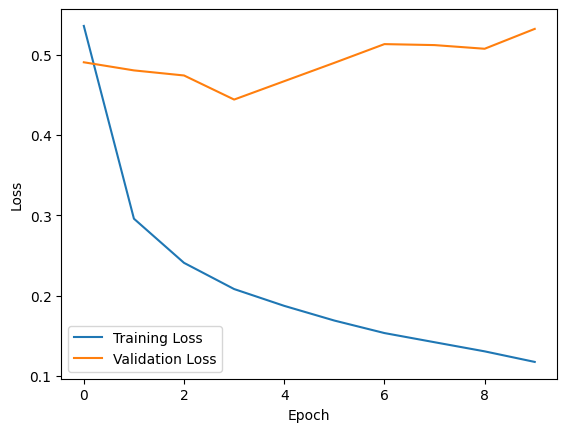

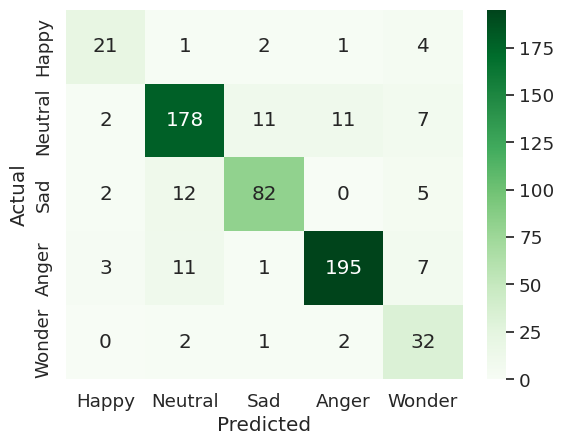

Testing finished with Loss:  0.44 | U_Accuracy:  0.83 | W_Accuracy:  0.86 | Precision:  0.87 | Recall:  0.86 | f1:  0.86
Accuracy per class:
Class 0: 0.7241379310344828
Class 1: 0.8516746411483254
Class 2: 0.8118811881188119
Class 3: 0.8986175115207373
Class 4: 0.8648648648648649


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 404.27 seconds, Training Loss:  0.55, Validation Loss: 0.51, Validation Accuracy:  0.82


Epoch: 2 finished in 404.20 seconds, Training Loss:  0.29, Validation Loss: 0.49, Validation Accuracy:  0.82


Epoch: 3 finished in 404.27 seconds, Training Loss:  0.24, Validation Loss: 0.49, Validation Accuracy:  0.83


...

Epoch: 6 finished in 404.17 seconds, Training Loss:  0.16, Validation Loss: 0.49, Validation Accuracy:  0.83


Epoch: 7 finished in 404.15 seconds, Training Loss:  0.15, Validation Loss: 0.50, Validation Accuracy:  0.81


Epoch: 8 finished in 404.03 seconds, Training Loss:  0.14, Validation Loss: 0.51, Validation Accuracy:  0.82


Epoch: 9 finished in 403.90 seconds, Training Loss:  0.13, Validation Loss: 0.63, Validation Accuracy:  0.81


Epoch: 10 finished in 403.92 seconds, Training Loss:  0.12, Validation Loss: 0.58, Validation Accuracy:  0.82
Each epoch took 404.15 seconds in average.


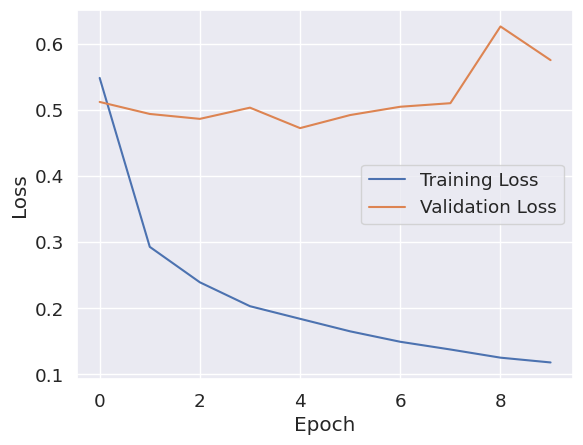

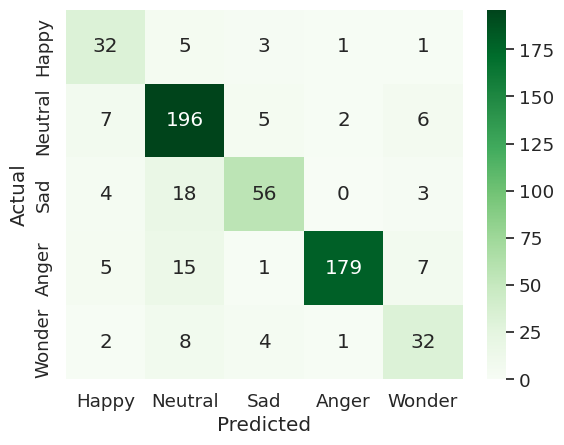

Testing finished with Loss:  0.49 | U_Accuracy:  0.78 | W_Accuracy:  0.83 | Precision:  0.84 | Recall:  0.83 | f1:  0.84
Accuracy per class:
Class 0: 0.7619047619047619
Class 1: 0.9074074074074074
Class 2: 0.691358024691358
Class 3: 0.8647342995169082
Class 4: 0.6808510638297872


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 399.08 seconds, Training Loss:  0.62, Validation Loss: 0.50, Validation Accuracy:  0.82


Epoch: 2 finished in 399.11 seconds, Training Loss:  0.31, Validation Loss: 0.48, Validation Accuracy:  0.83


Epoch: 3 finished in 399.04 seconds, Training Loss:  0.26, Validation Loss: 0.47, Validation Accuracy:  0.84


...

Epoch: 6 finished in 398.76 seconds, Training Loss:  0.18, Validation Loss: 0.48, Validation Accuracy:  0.85


Epoch: 7 finished in 398.80 seconds, Training Loss:  0.16, Validation Loss: 0.49, Validation Accuracy:  0.85


Epoch: 8 finished in 398.83 seconds, Training Loss:  0.15, Validation Loss: 0.48, Validation Accuracy:  0.84


Epoch: 9 finished in 398.97 seconds, Training Loss:  0.13, Validation Loss: 0.53, Validation Accuracy:  0.84


Epoch: 10 finished in 398.86 seconds, Training Loss:  0.13, Validation Loss: 0.51, Validation Accuracy:  0.84
Each epoch took 398.92 seconds in average.


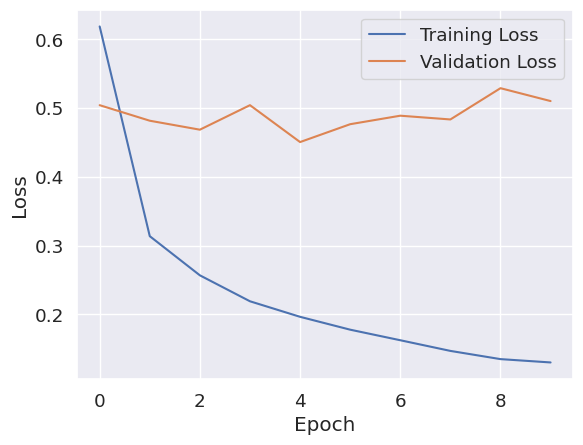

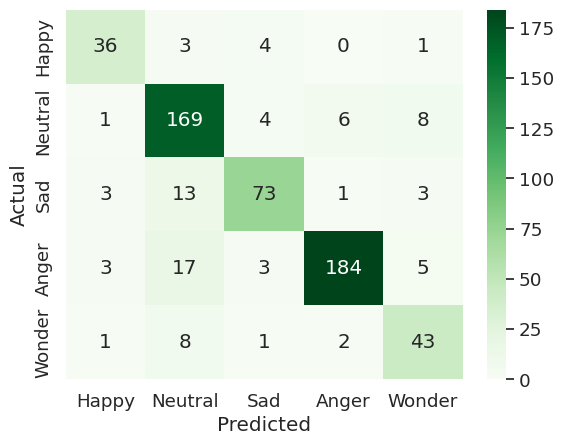

Testing finished with Loss:  0.49 | U_Accuracy:  0.83 | W_Accuracy:  0.85 | Precision:  0.86 | Recall:  0.85 | f1:  0.85
Accuracy per class:
Class 0: 0.8181818181818182
Class 1: 0.898936170212766
Class 2: 0.7849462365591398
Class 3: 0.8679245283018868
Class 4: 0.7818181818181819


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 406.85 seconds, Training Loss:  0.54, Validation Loss: 0.49, Validation Accuracy:  0.83


Epoch: 2 finished in 406.80 seconds, Training Loss:  0.30, Validation Loss: 0.57, Validation Accuracy:  0.79


Epoch: 3 finished in 406.78 seconds, Training Loss:  0.25, Validation Loss: 0.45, Validation Accuracy:  0.85


...

Epoch: 6 finished in 407.18 seconds, Training Loss:  0.17, Validation Loss: 0.45, Validation Accuracy:  0.85


Epoch: 7 finished in 407.02 seconds, Training Loss:  0.15, Validation Loss: 0.47, Validation Accuracy:  0.83


Epoch: 8 finished in 407.02 seconds, Training Loss:  0.14, Validation Loss: 0.46, Validation Accuracy:  0.84


Epoch: 9 finished in 407.00 seconds, Training Loss:  0.13, Validation Loss: 0.55, Validation Accuracy:  0.81


Epoch: 10 finished in 407.00 seconds, Training Loss:  0.12, Validation Loss: 0.47, Validation Accuracy:  0.85
Each epoch took 406.98 seconds in average.


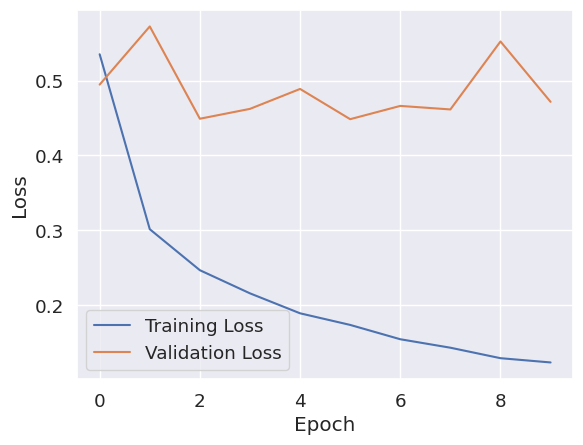

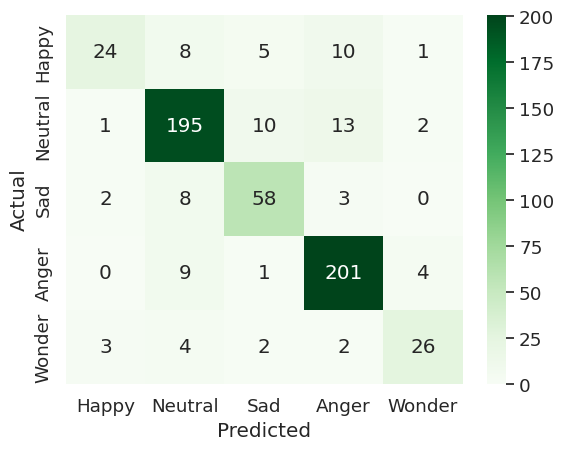

Testing finished with Loss:  0.45 | U_Accuracy:  0.77 | W_Accuracy:  0.85 | Precision:  0.85 | Recall:  0.85 | f1:  0.85
Accuracy per class:
Class 0: 0.5
Class 1: 0.8823529411764706
Class 2: 0.8169014084507042
Class 3: 0.9348837209302325
Class 4: 0.7027027027027027


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 402.15 seconds, Training Loss:  0.62, Validation Loss: 0.45, Validation Accuracy:  0.85


Epoch: 2 finished in 402.18 seconds, Training Loss:  0.33, Validation Loss: 0.40, Validation Accuracy:  0.87


Epoch: 3 finished in 402.18 seconds, Training Loss:  0.27, Validation Loss: 0.46, Validation Accuracy:  0.84


...

Epoch: 6 finished in 402.10 seconds, Training Loss:  0.19, Validation Loss: 0.45, Validation Accuracy:  0.85


Epoch: 7 finished in 402.12 seconds, Training Loss:  0.18, Validation Loss: 0.43, Validation Accuracy:  0.86


Epoch: 8 finished in 402.05 seconds, Training Loss:  0.16, Validation Loss: 0.42, Validation Accuracy:  0.86


Epoch: 9 finished in 402.08 seconds, Training Loss:  0.15, Validation Loss: 0.45, Validation Accuracy:  0.87


Epoch: 10 finished in 402.11 seconds, Training Loss:  0.14, Validation Loss: 0.47, Validation Accuracy:  0.85
Each epoch took 402.12 seconds in average.


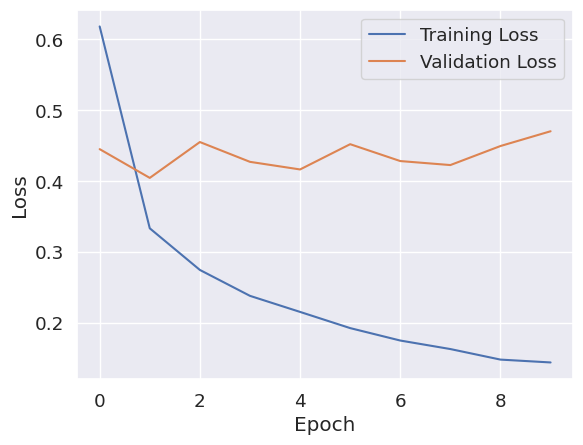

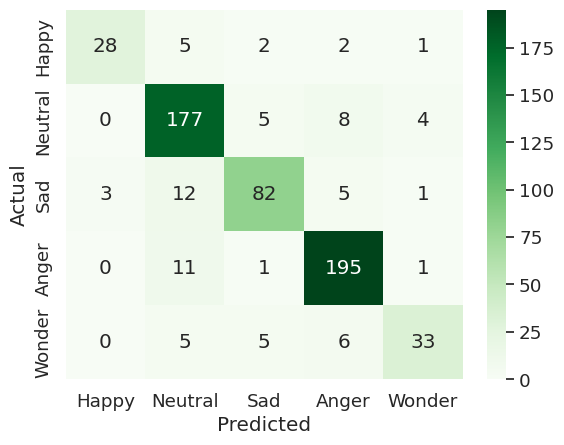

Testing finished with Loss:  0.40 | U_Accuracy:  0.81 | W_Accuracy:  0.87 | Precision:  0.87 | Recall:  0.87 | f1:  0.87
Accuracy per class:
Class 0: 0.7368421052631579
Class 1: 0.9123711340206185
Class 2: 0.7961165048543689
Class 3: 0.9375
Class 4: 0.673469387755102


In [15]:
reset_seed(42)
counter = 1
loader_lists = []

for trainset_indices, trainset, valset in zip(folds_indices, folds_trains, folds_vals):
    audios_to_aug = [audio for (ind,audio) in enumerate(audios) if ind in trainset_indices]
    audio_gender_to_aug = [name[0] for (ind,name) in enumerate(file_names) if ind in trainset_indices]
    audio_emo_to_aug = [emotion for (ind,emotion) in enumerate(emotions) if ind in trainset_indices]

    segments ={}


    for emotion in ['H', 'W', 'S', 'A', 'N']:

        audiosF1 = [audio_data[:len(audio_data)//2] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'F' and emo == emotion)]
        audiosF2 = [audio_data[len(audio_data)//2:] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'F' and emo == emotion)]
        audiosM1 = [audio_data[:len(audio_data)//2] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'M' and emo == emotion)]
        audiosM2 = [audio_data[len(audio_data)//2:] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'M' and emo == emotion)]

        segments[emotion] = [(audiosF1, audiosF2), (audiosM1, audiosM2)]

    
    augmented_audios = []
    augmented_labels = []
    augmented_emotions = []

    augmentation_need = {
        'H': 9,
        'W': 9,
        'S': 4,
        'A': 1,
        'N': 1
        }
    
    for category in segments:
        for gender_segments in segments[category]:
            for audio in gender_segments[0]:
                choice = random.sample(gender_segments[1], augmentation_need[category])
                for ch in choice:
                    new_speech = np.concatenate((audio, ch))
                    augmented_audios.append(new_speech)
                    augmented_emotions.append(category)
                    augmented_labels.append(emo2num[category])


    augmented_samplerates = []
    augmeted_features = []


    for audio in augmented_audios:

        input_features = whisper_tiny_processor(audio, sampling_rate=16000, return_tensors="pt").input_features

        augmented_samplerates.append(16000)
        augmeted_features.append(input_features.squeeze(0))


    Aug = AudioDataSet(augmeted_features, augmented_labels, [' ']*len(augmeted_features), [' ']*len(augmeted_features))
    concatenated_dataset = ConcatDataset([trainset, Aug])


    train_loader = DataLoader(concatenated_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(valset, batch_size=4, shuffle=False)


    model = WhisAttSumModel()

    for param in model.parameters():
        param.requires_grad = False

    for param in model.projector.parameters():
        param.requires_grad = True

    for param in model.attention_scorer.parameters():
        param.requires_grad = True

    for param in model.classifier.parameters():
        param.requeres_grad = True

    for param in model.layernorm.parameters():
        param.requires_grad = True

    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    training_losses1, valid_losses1 = train(model, f'whisper_small_att_aug_fold{counter}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=10)
    

    plt.plot(training_losses1, label='Training Loss')
    plt.plot(valid_losses1, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    model.load_state_dict(torch.load(f'whisper_small_att_aug_fold{counter}.bin'))
    test(model, torch.nn.CrossEntropyLoss(), val_loader)
    counter += 1

## testing with 4f

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


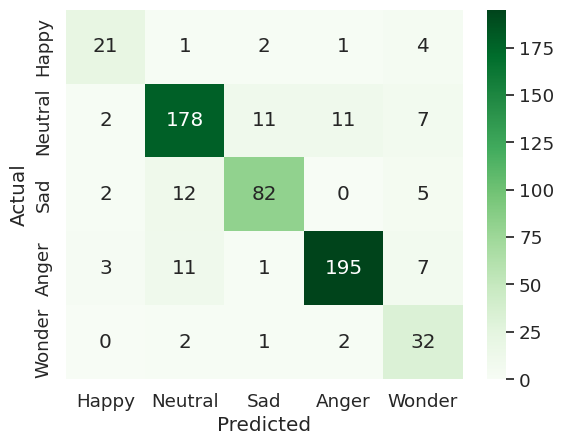

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.4442215722598035 | U_Accuracy: 0.8302352273374446 | W_Accuracy: 0.8566610455311973 | Precision: 0.8659115952054248 | Recall: 0.8566610455311973 | f1: 0.8593272388791791
Accuracy per class:
Class 0: 0.7241379310344828
Class 1: 0.8516746411483254
Class 2: 0.8118811881188119
Class 3: 0.8986175115207373
Class 4: 0.8648648648648649


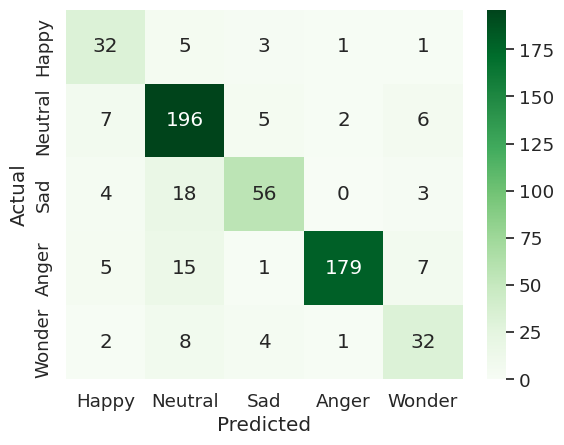

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.4863818279380016 | U_Accuracy: 0.7812511114700446 | W_Accuracy: 0.8347386172006745 | Precision: 0.8444023045231015 | Recall: 0.8347386172006745 | f1: 0.8362891596938965
Accuracy per class:
Class 0: 0.7619047619047619
Class 1: 0.9074074074074074
Class 2: 0.691358024691358
Class 3: 0.8647342995169082
Class 4: 0.6808510638297872


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


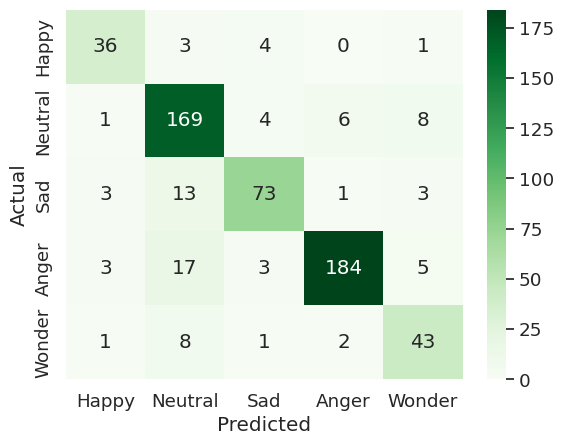

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.48887892464188404 | U_Accuracy: 0.8303613870147586 | W_Accuracy: 0.8530405405405406 | Precision: 0.8592845990447712 | Recall: 0.8530405405405406 | f1: 0.8542258849353577
Accuracy per class:
Class 0: 0.8181818181818182
Class 1: 0.898936170212766
Class 2: 0.7849462365591398
Class 3: 0.8679245283018868
Class 4: 0.7818181818181819


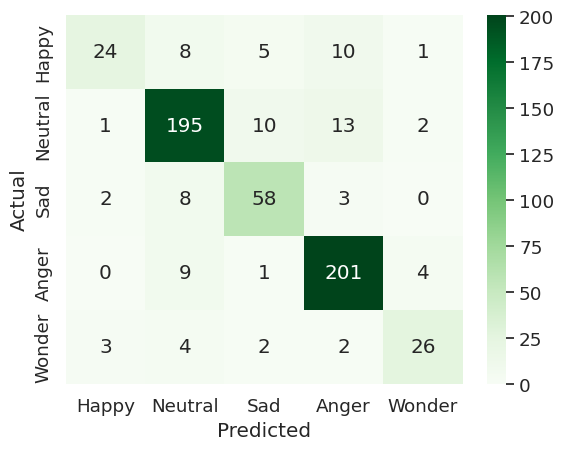

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.4484388728711024 | U_Accuracy: 0.767368154652022 | W_Accuracy: 0.8513513513513513 | Precision: 0.8493849812972751 | Recall: 0.8513513513513513 | f1: 0.8469576725154032
Accuracy per class:
Class 0: 0.5
Class 1: 0.8823529411764706
Class 2: 0.8169014084507042
Class 3: 0.9348837209302325
Class 4: 0.7027027027027027


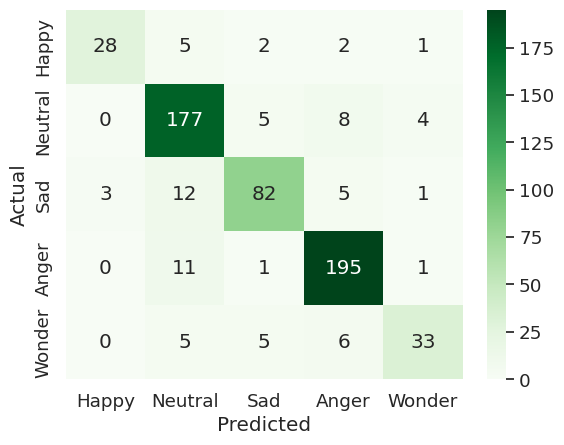

Testing finished with Loss: 0.40461481779159325 | U_Accuracy: 0.8112598263786495 | W_Accuracy: 0.8699324324324325 | Precision: 0.8698393704309451 | Recall: 0.8699324324324325 | f1: 0.8679081814220334
Accuracy per class:
Class 0: 0.7368421052631579
Class 1: 0.9123711340206185
Class 2: 0.7961165048543689
Class 3: 0.9375
Class 4: 0.673469387755102


In [13]:
reset_seed(42)
for i, val_set in enumerate(folds_vals):
    val_loader = DataLoader(val_set, batch_size=4, shuffle=False)
    model = WhisAttSumModel().to(device)
    for param in model.parameters():
        param.requires_grad = False    
    model.load_state_dict(torch.load(f'whisper_small_att_aug_fold{i +1}.bin'))
    test(model, torch.nn.CrossEntropyLoss(), val_loader)

## multihead

In [ ]:
reset_seed(42)

class WhisAttSumModelhead (nn.Module):
  def __init__(self, heads=2, dropout = 0.5, dimention=128):
    super(WhisAttSumModelhead, self).__init__()
    self.whisperencoder = WhisperForAudioClassification.from_pretrained('whisper_small').encoder.to(device)
    self.projector = WhisperForAudioClassification.from_pretrained('whisper_small').projector.to(device)
    self.layernorm = nn.LayerNorm(256)
    # self.attention_scorer = nn.Linear(in_features=256, out_features=1, bias=True)
    self.multihead = nn.MultiheadAttention(embed_dim=dimention, kdim=256, vdim=256, num_heads=heads, batch_first=True, dropout=dropout)
    self.classifier = torch.nn.Linear(in_features=dimention, out_features=5)
    self.attparam = nn.Parameter(torch.rand(1, dimention))

  def forward(self, x):
    out = self.whisperencoder(x).last_hidden_state
    out = self.projector(out)
    out = self.layernorm(out)
    stacked_param = self.attparam.unsqueeze(0).repeat(x.size()[0], 1, 1)
    weighted_output, attn_output_weights= self.multihead(query=stacked_param , key=out, value=out)
    out = self.classifier(weighted_output.squeeze(dim=1))

    return out

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 410.76 seconds, Training Loss:  0.54, Validation Loss: 0.45, Validation Accuracy:  0.84


Epoch: 2 finished in 410.82 seconds, Training Loss:  0.25, Validation Loss: 0.47, Validation Accuracy:  0.83


Epoch: 3 finished in 410.86 seconds, Training Loss:  0.18, Validation Loss: 0.44, Validation Accuracy:  0.85


Epoch: 4 finished in 410.78 seconds, Training Loss:  0.13, Validation Loss: 0.47, Validation Accuracy:  0.85


...

Epoch: 6 finished in 410.81 seconds, Training Loss:  0.08, Validation Loss: 0.55, Validation Accuracy:  0.85


Epoch: 7 finished in 410.74 seconds, Training Loss:  0.08, Validation Loss: 0.56, Validation Accuracy:  0.83


Epoch: 8 finished in 410.75 seconds, Training Loss:  0.07, Validation Loss: 0.59, Validation Accuracy:  0.85


Epoch: 9 finished in 410.74 seconds, Training Loss:  0.06, Validation Loss: 0.58, Validation Accuracy:  0.84


Epoch: 10 finished in 410.79 seconds, Training Loss:  0.04, Validation Loss: 0.70, Validation Accuracy:  0.83
Each epoch took 410.79 seconds in average.


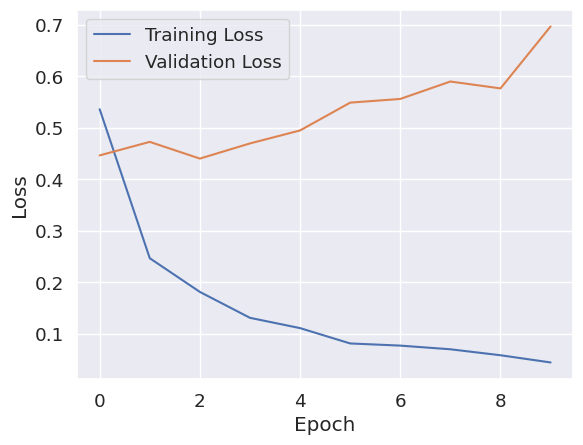

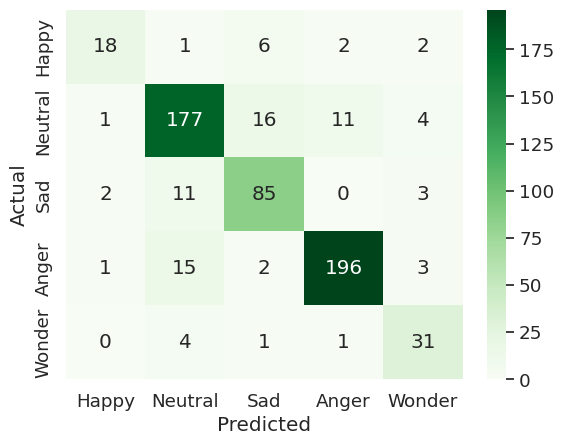

Testing finished with Loss:  0.49 | U_Accuracy:  0.81 | W_Accuracy:  0.85 | Precision:  0.86 | Recall:  0.85 | f1:  0.86
Accuracy per class:
Class 0: 0.6206896551724138
Class 1: 0.84688995215311
Class 2: 0.8415841584158416
Class 3: 0.9032258064516129
Class 4: 0.8378378378378378


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 405.30 seconds, Training Loss:  0.60, Validation Loss: 0.49, Validation Accuracy:  0.82


Epoch: 2 finished in 405.36 seconds, Training Loss:  0.27, Validation Loss: 0.46, Validation Accuracy:  0.82


Epoch: 3 finished in 405.24 seconds, Training Loss:  0.21, Validation Loss: 0.49, Validation Accuracy:  0.85


...

Epoch: 6 finished in 405.27 seconds, Training Loss:  0.12, Validation Loss: 0.55, Validation Accuracy:  0.84


Epoch: 7 finished in 405.33 seconds, Training Loss:  0.09, Validation Loss: 0.63, Validation Accuracy:  0.85


Epoch: 8 finished in 405.31 seconds, Training Loss:  0.08, Validation Loss: 0.54, Validation Accuracy:  0.86


Epoch: 9 finished in 405.32 seconds, Training Loss:  0.07, Validation Loss: 0.66, Validation Accuracy:  0.83


Epoch: 10 finished in 405.36 seconds, Training Loss:  0.06, Validation Loss: 0.70, Validation Accuracy:  0.85
Each epoch took 405.29 seconds in average.


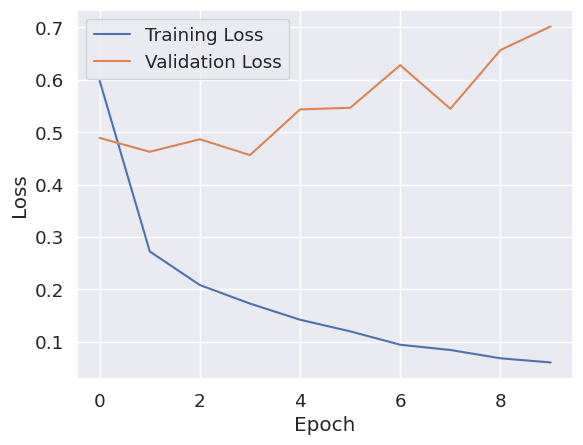

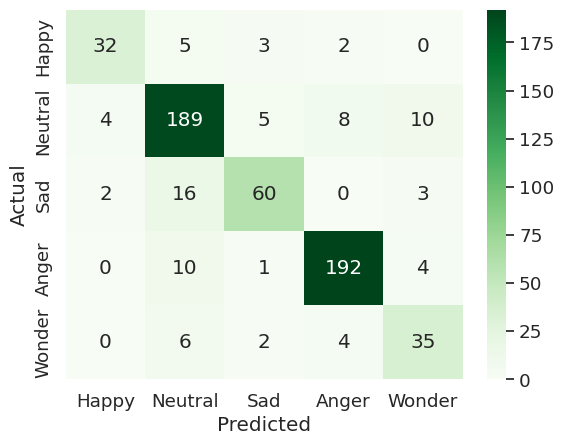

Testing finished with Loss:  0.54 | U_Accuracy:  0.81 | W_Accuracy:  0.86 | Precision:  0.86 | Recall:  0.86 | f1:  0.86
Accuracy per class:
Class 0: 0.7619047619047619
Class 1: 0.875
Class 2: 0.7407407407407407
Class 3: 0.927536231884058
Class 4: 0.7446808510638298


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 400.43 seconds, Training Loss:  0.54, Validation Loss: 0.50, Validation Accuracy:  0.84


Epoch: 2 finished in 400.11 seconds, Training Loss:  0.29, Validation Loss: 0.43, Validation Accuracy:  0.85


Epoch: 3 finished in 400.06 seconds, Training Loss:  0.23, Validation Loss: 0.44, Validation Accuracy:  0.86


...

Epoch: 6 finished in 400.04 seconds, Training Loss:  0.14, Validation Loss: 0.51, Validation Accuracy:  0.85


Epoch: 7 finished in 399.97 seconds, Training Loss:  0.12, Validation Loss: 0.49, Validation Accuracy:  0.86


Epoch: 8 finished in 400.05 seconds, Training Loss:  0.11, Validation Loss: 0.52, Validation Accuracy:  0.87


Epoch: 9 finished in 400.06 seconds, Training Loss:  0.10, Validation Loss: 0.52, Validation Accuracy:  0.88


Epoch: 10 finished in 400.00 seconds, Training Loss:  0.08, Validation Loss: 0.56, Validation Accuracy:  0.87
Each epoch took 400.07 seconds in average.


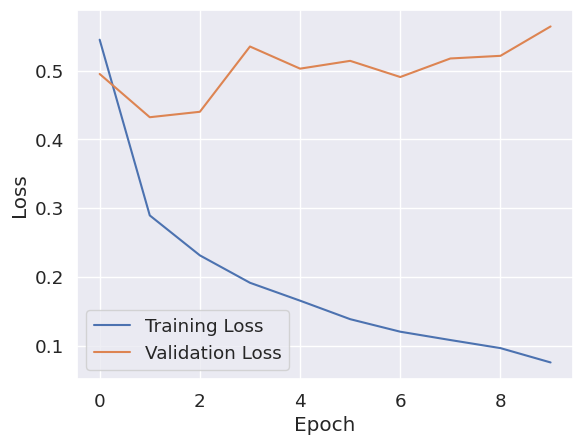

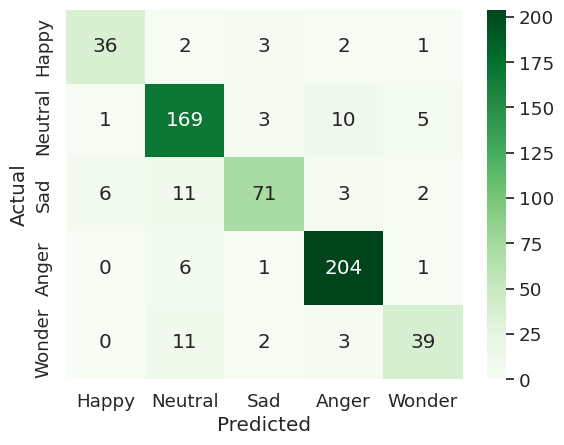

Testing finished with Loss:  0.52 | U_Accuracy:  0.83 | W_Accuracy:  0.88 | Precision:  0.88 | Recall:  0.88 | f1:  0.87
Accuracy per class:
Class 0: 0.8181818181818182
Class 1: 0.898936170212766
Class 2: 0.7634408602150538
Class 3: 0.9622641509433962
Class 4: 0.7090909090909091


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 408.07 seconds, Training Loss:  0.55, Validation Loss: 0.46, Validation Accuracy:  0.84


Epoch: 2 finished in 408.07 seconds, Training Loss:  0.26, Validation Loss: 0.50, Validation Accuracy:  0.84


Epoch: 3 finished in 408.02 seconds, Training Loss:  0.18, Validation Loss: 0.51, Validation Accuracy:  0.84


...

Epoch: 6 finished in 408.07 seconds, Training Loss:  0.10, Validation Loss: 0.52, Validation Accuracy:  0.85


Epoch: 7 finished in 408.11 seconds, Training Loss:  0.09, Validation Loss: 0.50, Validation Accuracy:  0.88


Epoch: 8 finished in 408.07 seconds, Training Loss:  0.07, Validation Loss: 0.58, Validation Accuracy:  0.87


Epoch: 9 finished in 408.09 seconds, Training Loss:  0.07, Validation Loss: 0.64, Validation Accuracy:  0.86


Epoch: 10 finished in 408.02 seconds, Training Loss:  0.06, Validation Loss: 0.52, Validation Accuracy:  0.88
Each epoch took 408.07 seconds in average.


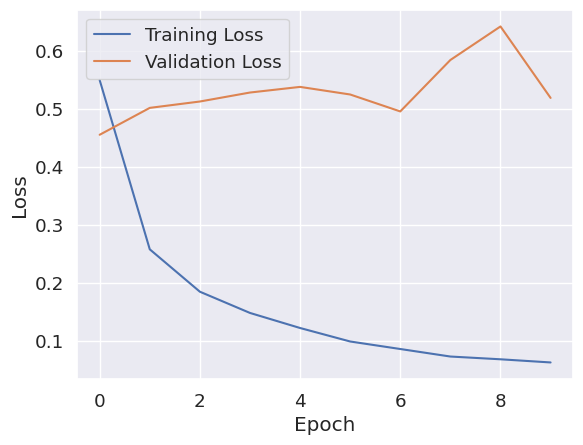

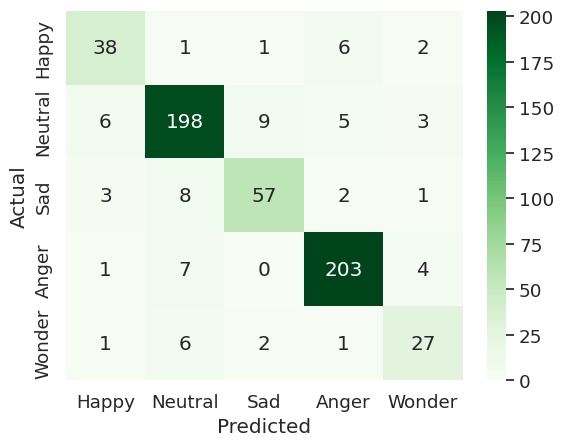

Testing finished with Loss:  0.50 | U_Accuracy:  0.83 | W_Accuracy:  0.88 | Precision:  0.88 | Recall:  0.88 | f1:  0.88
Accuracy per class:
Class 0: 0.7916666666666666
Class 1: 0.8959276018099548
Class 2: 0.8028169014084507
Class 3: 0.9441860465116279
Class 4: 0.7297297297297297


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 403.16 seconds, Training Loss:  0.56, Validation Loss: 0.39, Validation Accuracy:  0.87


Epoch: 2 finished in 403.07 seconds, Training Loss:  0.29, Validation Loss: 0.41, Validation Accuracy:  0.87


Epoch: 3 finished in 403.03 seconds, Training Loss:  0.22, Validation Loss: 0.44, Validation Accuracy:  0.88


...

Epoch: 6 finished in 403.20 seconds, Training Loss:  0.12, Validation Loss: 0.49, Validation Accuracy:  0.88


Epoch: 7 finished in 403.11 seconds, Training Loss:  0.10, Validation Loss: 0.50, Validation Accuracy:  0.88


Epoch: 8 finished in 403.10 seconds, Training Loss:  0.09, Validation Loss: 0.61, Validation Accuracy:  0.87


Epoch: 9 finished in 403.03 seconds, Training Loss:  0.08, Validation Loss: 0.53, Validation Accuracy:  0.88


Epoch: 10 finished in 403.04 seconds, Training Loss:  0.06, Validation Loss: 0.60, Validation Accuracy:  0.88
Each epoch took 403.10 seconds in average.


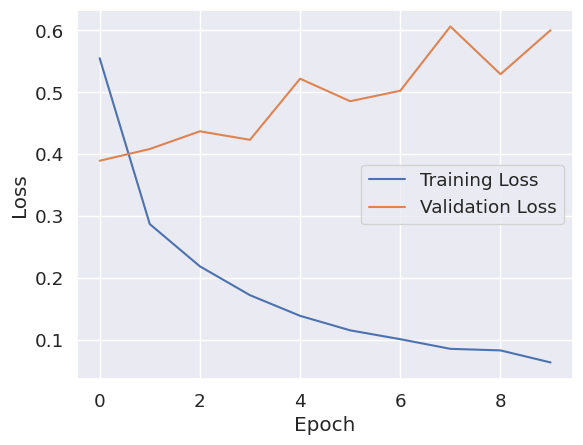

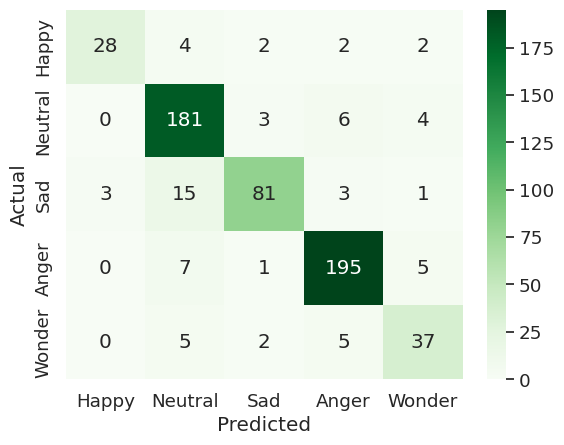

Testing finished with Loss:  0.44 | U_Accuracy:  0.83 | W_Accuracy:  0.88 | Precision:  0.88 | Recall:  0.88 | f1:  0.88
Accuracy per class:
Class 0: 0.7368421052631579
Class 1: 0.9329896907216495
Class 2: 0.7864077669902912
Class 3: 0.9375
Class 4: 0.7551020408163265


In [17]:
reset_seed(42)
counter = 1
loader_lists = []

for trainset_indices, trainset, valset in zip(folds_indices, folds_trains, folds_vals):
    audios_to_aug = [audio for (ind,audio) in enumerate(audios) if ind in trainset_indices]
    audio_gender_to_aug = [name[0] for (ind,name) in enumerate(file_names) if ind in trainset_indices]
    audio_emo_to_aug = [emotion for (ind,emotion) in enumerate(emotions) if ind in trainset_indices]

    segments ={}


    for emotion in ['H', 'W', 'S', 'A', 'N']:

        audiosF1 = [audio_data[:len(audio_data)//2] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'F' and emo == emotion)]
        audiosF2 = [audio_data[len(audio_data)//2:] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'F' and emo == emotion)]
        audiosM1 = [audio_data[:len(audio_data)//2] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'M' and emo == emotion)]
        audiosM2 = [audio_data[len(audio_data)//2:] for (audio_data, gen, emo) in zip(audios_to_aug, audio_gender_to_aug, audio_emo_to_aug) if (gen == 'M' and emo == emotion)]

        segments[emotion] = [(audiosF1, audiosF2), (audiosM1, audiosM2)]

    
    augmented_audios = []
    augmented_labels = []
    augmented_emotions = []

    augmentation_need = {
        'H': 9,
        'W': 9,
        'S': 4,
        'A': 1,
        'N': 1
        }
    
    for category in segments:
        for gender_segments in segments[category]:
            for audio in gender_segments[0]:
                choice = random.sample(gender_segments[1], augmentation_need[category])
                for ch in choice:
                    new_speech = np.concatenate((audio, ch))
                    augmented_audios.append(new_speech)
                    augmented_emotions.append(category)
                    augmented_labels.append(emo2num[category])


    augmented_samplerates = []
    augmeted_features = []


    for audio in augmented_audios:

        input_features = whisper_tiny_processor(audio, sampling_rate=16000, return_tensors="pt").input_features

        augmented_samplerates.append(16000)
        augmeted_features.append(input_features.squeeze(0))


    Aug = AudioDataSet(augmeted_features, augmented_labels, [' ']*len(augmeted_features), [' ']*len(augmeted_features))
    concatenated_dataset = ConcatDataset([trainset, Aug])


    train_loader = DataLoader(concatenated_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(valset, batch_size=4, shuffle=False)


    model = WhisAttSumModelhead(heads=4, dropout=0.5)
    for param in model.parameters():
        param.requires_grad = False

    for param in model.projector.parameters():
        param.requires_grad = True

    for param in model.layernorm.parameters():
        param.requires_grad = True

    model.attparam.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

    for param in model.multihead.parameters():
        param.requires_grad = True

    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    training_losses1, valid_losses1 = train(model, f'whisper_small_mhatt_aug_fold{counter}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=10)
    

    plt.plot(training_losses1, label='Training Loss')
    plt.plot(valid_losses1, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    model.load_state_dict(torch.load(f'whisper_small_mhatt_aug_fold{counter}.bin'))
    test(model, torch.nn.CrossEntropyLoss(), val_loader)
    counter += 1

## testing with 4f

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


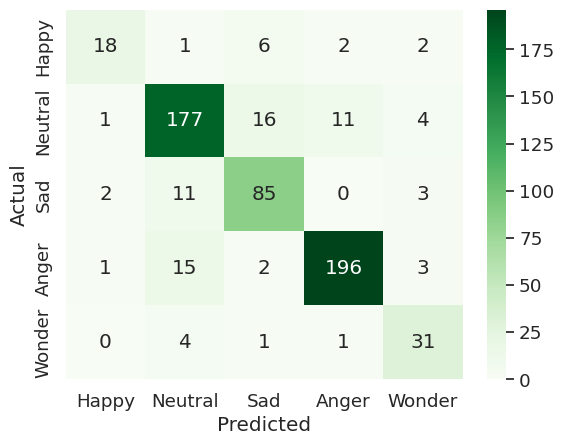

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.49499428726149874 | U_Accuracy: 0.8100454820061632 | W_Accuracy: 0.8549747048903878 | Precision: 0.8580631378569532 | Recall: 0.8549747048903878 | f1: 0.8552404232782218
Accuracy per class:
Class 0: 0.6206896551724138
Class 1: 0.84688995215311
Class 2: 0.8415841584158416
Class 3: 0.9032258064516129
Class 4: 0.8378378378378378


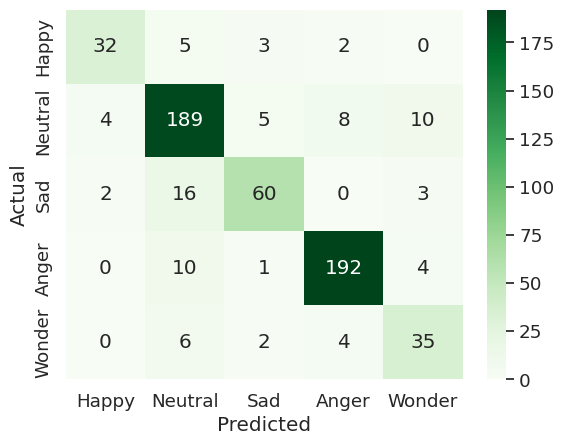

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.5447299083620689 | U_Accuracy: 0.809972517118678 | W_Accuracy: 0.8566610455311973 | Precision: 0.858386083708505 | Recall: 0.8566610455311973 | f1: 0.8566080347301696
Accuracy per class:
Class 0: 0.7619047619047619
Class 1: 0.875
Class 2: 0.7407407407407407
Class 3: 0.927536231884058
Class 4: 0.7446808510638298


Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


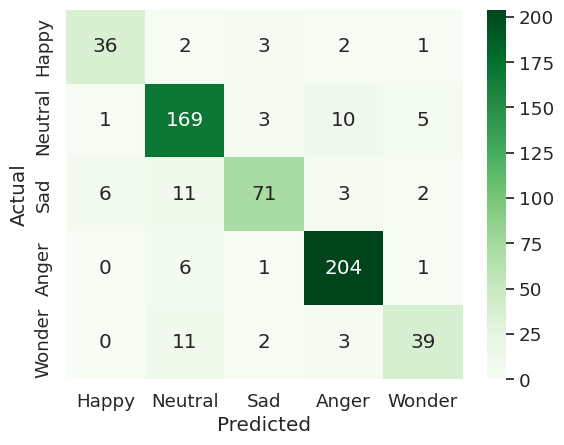

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.5214927978963377 | U_Accuracy: 0.8303827817287888 | W_Accuracy: 0.8766891891891891 | Precision: 0.8758974857608495 | Recall: 0.8766891891891891 | f1: 0.8748234125935742
Accuracy per class:
Class 0: 0.8181818181818182
Class 1: 0.898936170212766
Class 2: 0.7634408602150538
Class 3: 0.9622641509433962
Class 4: 0.7090909090909091


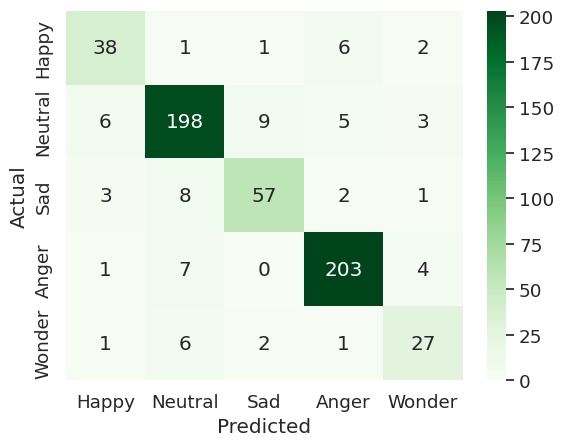

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.4953825484035037 | U_Accuracy: 0.832865389225286 | W_Accuracy: 0.8834459459459459 | Precision: 0.8832866485929498 | Recall: 0.8834459459459459 | f1: 0.8833305708006555
Accuracy per class:
Class 0: 0.7916666666666666
Class 1: 0.8959276018099548
Class 2: 0.8028169014084507
Class 3: 0.9441860465116279
Class 4: 0.7297297297297297


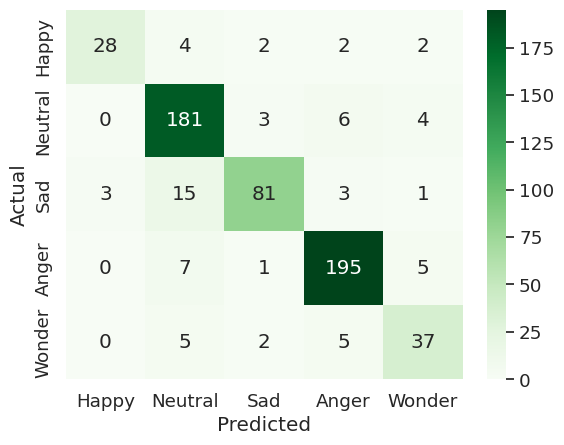

Testing finished with Loss: 0.43692688140534397 | U_Accuracy: 0.829768320758285 | W_Accuracy: 0.8817567567567568 | Precision: 0.8833170900375439 | Recall: 0.8817567567567568 | f1: 0.8806182732838256
Accuracy per class:
Class 0: 0.7368421052631579
Class 1: 0.9329896907216495
Class 2: 0.7864077669902912
Class 3: 0.9375
Class 4: 0.7551020408163265


In [17]:
reset_seed(42)
for i, val_set in enumerate(folds_vals):
    val_loader = DataLoader(val_set, batch_size=4, shuffle=False)
    model = WhisAttSumModelhead(heads=4, dropout=0.5).to(device)
    for param in model.parameters():
        param.requires_grad = False    
    model.load_state_dict(torch.load(f'whisper_small_mhatt_aug_fold{i +1}.bin'))
    test(model, torch.nn.CrossEntropyLoss(), val_loader)